# Recomputing the Köppen ram-pressure criterion for the MAUVE sample — Model A

**Date:** 2026-08-17  
**Scope:** the 40-galaxy MAUVE list, with 38 galaxies computable from Köppen/GoldMine inputs  
**Purpose:** reproduce the original Köppen et al. (2018) prescription and its published or directly reconstructed GoldMine inputs, while preserving the same detailed 31-cell workflow and visual diagnostics as the Model C notebook.

The key diagnostic is

$$
\mathcal{R}_{\rm RP}=\frac{p_{\rm def}}{p_{\rm loc}},\qquad
\Delta_{\rm RP}=\log_{10}\mathcal{R}_{\rm RP}.
$$

Köppen et al. classify $p_{\rm def}>2p_{\rm loc}$ as favouring **past stripping**. In this Model-A notebook, the classification uses their original escape-speed $p_{\rm loc}$, not the later LOS-versus-escape modification.

## 1. Exact Model-A roadmap

1. Preserve all 40 physical MAUVE identities and their MAUVE environmental-stage labels.
2. Use the 35 GoldMine-derived rows printed in Köppen et al. (2018) Appendix E directly.
3. For MAUVE galaxies absent from Appendix E, inspect all live GoldMine fields—not only the primary `MHI` column—including `MHI_GM`, `Aradius`, distance, inclination, and `WIDTHA`.
4. Reconstruct three additional rows (`NGC4189`, `NGC4567`, and `NGC4568`) using the same Köppen/Gavazzi equations. The GoldMine-to-Köppen rotation conversion
   $v_{\rm rot}=0.98\,\mathrm{WIDTHA}/(2\sin i)$ is empirically validated against the published Appendix-E rows.
5. Reconstruct the initial mass with $\log M_{\rm HI,0}=7.51+1.36\log(2R_{\rm opt})$, and set $R=R_{\rm opt}$ and $r_{\max}=1.5R_{\rm opt}$.
6. Recompute $r_{\rm strip}$ and $p_{\rm def}$ with the original Köppen profile, $g=2$, $a=15$, scaled $R_0$, and pressure conversion constant $0.0675$.
7. Recompute escape-only $p_{\rm loc}$ with the original Virgo beta models. The LOS comparison remains diagnostic only.
8. Retain published $p_{\rm cfg}$ where available.
9. Propagate uncertainties and show all 40 panels.

### Remaining non-computable GoldMine rows

`NGC4394` and `NGC4457` do have GoldMine `MHI_GM` and `WIDTHA`, but GoldMine reports inclination $i=0^\circ$. Because the original prescription requires division by $\sin i$, an inclination-corrected $v_{\rm rot}$ is undefined. They remain explicit rather than receiving a non-Köppen velocity substitution.

## 2. Provenance ledger

| Quantity | Source used here | Role / caveat |
|---|---|---|
| 35 published Model-A rows | Köppen et al. (2018), Appendix E | GoldMine-derived deficiency, M87 distance, optical radius, rotation velocity, and published pressures. |
| 5 Appendix-E-absent records | live GoldMine audit on 2026-08-17 | The audit includes both `MHI` and alternate `MHI_GM`, plus `Aradius`, distance, inclination, and `WIDTHA`. Three are fully computable; two have $i=0^\circ$. |
| Frozen local table | `koppen2018_goldmine_MAUVE_ModelA.csv` | Contains all 40 identities, separate `in_K18_catalogue` and `modelA_computable` flags, and row-level derivation notes. |
| Expected H I mass | Gavazzi et al. (2013), equation adopted by Köppen | $\log M_{\rm HI,0}=7.51+1.36\log D_{\rm opt}$. |
| Added-row rotation speed | live GoldMine `WIDTHA` and inclination | $0.98\,\mathrm{WIDTHA}/(2\sin i)$. The 0.98 factor reproduces 33 of 34 testable Appendix-E velocities closely; NGC4419 is a live-catalogue outlier. |
| MAUVE stage and LOS velocity | local master FITS | Stage is comparison-only; LOS velocity does not change Model-A $p_{\rm loc}$. |
| Galaxy colours | local `MAUVE_galaxy_colors.dat` | Fixed identity palette. |

Primary references:

- [Köppen et al. 2018](https://academic.oup.com/mnras/article/479/4/4367/5040236)
- [Gavazzi et al. 2013](https://www.aanda.org/articles/aa/pdf/2013/05/aa18789-12.pdf)
- [GoldMine database](https://goldmine.inaf.it/)
- [Köppen companion calculators](http://www.astrophysik.uni-kiel.de/~koeppen/JS/RPShome.html)

Appendix-E pressures are rounded. The three added rows are equation-level extensions using current GoldMine fields and are clearly distinguished from directly published rows.

In [1]:
from pathlib import Path
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.table import Table
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4g}")

RNG_SEED = 20260817
N_MC = 20_000
SIGMA_DEF_DEX = 0.22
SIGMA_LOG_ROPT_DEX = 0.08
VROT_FRACTIONAL_FALLBACK = 0.01
SIGMA_LOG_PLOC_DEX = np.log10(2.0)
M87_VLOS_KMS = 1256.0

GAVAZZI_C1 = 7.51
GAVAZZI_DIAMETER_SLOPE = 1.36
RESTORING_G = 2.0
STELLAR_BOOST_A = 15.0
R0_AT_ROPT_15_KPC = 2.0
KOPPEN_C1_PRESSURE = 0.0675

ICM_N0_CM3 = 0.04
ICM_RC_KPC = 13.4
ICM_BETA = 0.47
DM_RHO0_MSUN_PC3 = 3.8e-4
DM_RC_KPC = 320.0
G_KPC_KMS2_MSUN = 4.30091e-6

HERE = Path.cwd()
MASTER_PATH = HERE / "mauve_master_wiki_newclass.fits"
COLOR_PATH = HERE / "MAUVE_galaxy_colors.dat"
K18_GOLDMINE_PATH = HERE / "koppen2018_goldmine_MAUVE_ModelA.csv"

print(f"Working directory: {HERE}")
print(f"Monte Carlo draws per reproducible galaxy: {N_MC:,}")

Working directory: /Users/Igniz/Desktop/ICRAR/further
Monte Carlo draws per reproducible galaxy: 20,000


## 3. Assemble the 40-galaxy identity table

The MAUVE master file supplies only identity, stage, and the optional LOS-velocity comparison. All central Model-A galaxy properties come from the frozen Köppen/GoldMine table. Strict joins prevent a missing or duplicated object from silently entering the calculation.

In [2]:
def clean_text(value):
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8")
    return str(value).strip()


def read_mauve_colors(path):
    colors = {}
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip() or line.lstrip().startswith("#"):
                continue
            fields = line.split()
            colors[fields[1]] = fields[3]
    return colors


master = Table.read(MASTER_PATH).to_pandas()
master["Galaxy"] = master["Galaxy"].map(clean_text)
master["stage"] = master["class"].astype(int)
master["stage_label"] = master["stage"].map({1: "pre-peak", 2: "close-to-peak", 3: "post-peak"})

k18 = pd.read_csv(K18_GOLDMINE_PATH)
k18["in_K18_catalogue"] = k18["in_K18_catalogue"].astype(bool)
galaxy_colors = read_mauve_colors(COLOR_PATH)

assert len(master) == 40 and master["Galaxy"].is_unique
assert len(k18) == 40 and k18["Galaxy"].is_unique
assert set(master["Galaxy"]) == set(k18["Galaxy"])
assert set(master["Galaxy"]).issubset(galaxy_colors)

sample = master[["Galaxy", "vel", "stage", "stage_label"]].merge(
    k18.drop(columns=["MAUVE_stage", "MAUVE_stage_label"]),
    on="Galaxy", how="left", validate="one_to_one",
)
sample["galaxy_color"] = sample["Galaxy"].map(galaxy_colors)

# Use the same frozen literature e_vrot snapshot as the AMIGA/Model-C notebooks.
# The Model-A central velocities remain the Köppen/GoldMine values.
EVROT_CSV = """Galaxy,e_vrot_literature
NGC4189,4.7
NGC4192,
NGC4222,
NGC4254,8.8
NGC4294,2.1
NGC4321,6.2
NGC4351,1.9
NGC4383,2.5
NGC4396,2.2
NGC4535,6.8
NGC4567,5.3
NGC4568,7.8
NGC4298,5.2
NGC4302,
NGC4330,3.4
NGC4388,
NGC4402,2.8
NGC4424,1.1
NGC4501,4.4
NGC4522,2.5
NGC4654,2.1
NGC4694,1.6
NGC4064,2.9
NGC4216,
NGC4293,4.4
NGC4380,3.7
NGC4394,8.7
NGC4405,2.9
NGC4419,2.6
NGC4450,4.6
IC3392,2.4
NGC4457,3.2
NGC4548,4.8
NGC4569,5.4
NGC4579,7.3
NGC4580,3.2
NGC4606,2.2
NGC4607,
NGC4689,2.4
NGC4698,3.2
"""
evrot_snapshot = pd.read_csv(StringIO(EVROT_CSV))
sample = sample.merge(evrot_snapshot, on="Galaxy", how="left", validate="one_to_one")
has_literature_evrot = (
    np.isfinite(sample["e_vrot_literature"]) & (sample["e_vrot_literature"] > 0)
)
sample["e_vrot_used"] = np.where(
    has_literature_evrot,
    sample["e_vrot_literature"],
    VROT_FRACTIONAL_FALLBACK * sample["vrot_ModelA_kms"],
)
sample["e_vrot_source"] = np.where(
    has_literature_evrot, "literature e_vrot", "1% of reported Model-A vrot",
)

display(sample[["Galaxy", "stage_label", "in_K18_catalogue", "modelA_computable",
                "vrot_ModelA_kms", "e_vrot_literature", "e_vrot_used",
                "e_vrot_source", "modelA_input_status", "GoldMine_live_audit_note"]])
print(f"Published Appendix-E rows: {sample['in_K18_catalogue'].sum()}/40")
print(f"Computable Model-A rows after full GoldMine audit: {sample['modelA_computable'].sum()}/40")

,Galaxy,stage_label,in_K18_catalogue,modelA_computable,vrot_ModelA_kms,e_vrot_literature,e_vrot_used,e_vrot_source,modelA_input_status,GoldMine_live_audit_note
0,NGC4189,pre-peak,False,True,179.6,4.7,4.7,literature e_vrot,recomputed from live GoldMine with Köppen equa...,"computed from GoldMine MHI, Aradius, distance,..."
1,NGC4192,pre-peak,True,True,234.7,NaN,2.347,1% of reported Model-A vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
2,NGC4222,pre-peak,True,True,113,NaN,1.13,1% of reported Model-A vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
3,NGC4254,pre-peak,True,True,271.4,8.8,8.8,literature e_vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
4,NGC4294,pre-peak,True,True,101.1,2.1,2.1,literature e_vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
5,NGC4321,pre-peak,True,True,268.8,6.2,6.2,literature e_vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
6,NGC4351,pre-peak,True,True,60.6,1.9,1.9,literature e_vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
7,NGC4383,pre-peak,True,True,123.6,2.5,2.5,literature e_vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
8,NGC4396,pre-peak,True,True,99,2.2,2.2,literature e_vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN
9,NGC4535,pre-peak,True,True,297.9,6.8,6.8,literature e_vrot,published Köppen 2018 Appendix E (GoldMine-der...,NaN


Published Appendix-E rows: 35/40
Computable Model-A rows after full GoldMine audit: 38/40


## 4. Frozen Köppen/GoldMine input snapshot

The table separates two provenance levels:

- `in_K18_catalogue=True`: the 35 GoldMine-derived rows printed directly in Appendix E;
- `modelA_computable=True`: those 35 plus NGC4189, NGC4567, and NGC4568 reconstructed from live GoldMine fields with the same equations.

NGC4394 and NGC4457 retain their GoldMine mass, radius, distance, and width fields, but no pressure is calculated because $i=0^\circ$ makes the required inclination correction singular.

For Monte Carlo propagation, the central $v_{\rm rot}$ remains the Model-A Köppen/GoldMine value. Its uncertainty uses the frozen literature `e_vrot` where finite and positive; otherwise it uses 1% of the reported Model-A velocity. No 15 km s$^{-1}$ floor is retained.

In [3]:
modela_input_columns = [
    "Galaxy", "stage_label", "in_K18_catalogue", "modelA_computable",
    "modelA_input_status", "DEF_ModelA", "R_M87_ModelA_mpc",
    "Ropt_ModelA_kpc", "vrot_ModelA_kms", "p_loc_K18", "p_cfg_K18", "p_def_K18",
    "logMHI_GoldMine_live", "MHI_GoldMine_field_used", "WIDTHA_GoldMine_live_kms",
    "inclination_GoldMine_live_deg", "vrot_ModelA_derivation",
]
display(sample[modela_input_columns])

available = sample["modelA_computable"]
assert sample["in_K18_catalogue"].sum() == 35
assert available.sum() == 38
assert sample.loc[available, ["DEF_ModelA", "R_M87_ModelA_mpc", "Ropt_ModelA_kpc", "vrot_ModelA_kms"]].notna().all().all()
print("Model-A central-input coverage: 38/40.")
print("Not computable because GoldMine inclination is zero: " + ", ".join(sample.loc[~available, "Galaxy"]))

,Galaxy,stage_label,in_K18_catalogue,modelA_computable,modelA_input_status,DEF_ModelA,R_M87_ModelA_mpc,Ropt_ModelA_kpc,vrot_ModelA_kms,p_loc_K18,p_cfg_K18,p_def_K18,logMHI_GoldMine_live,MHI_GoldMine_field_used,WIDTHA_GoldMine_live_kms,inclination_GoldMine_live_deg,vrot_ModelA_derivation
0,NGC4189,pre-peak,False,True,recomputed from live GoldMine with Köppen equa...,-0.09174,15.1,10.52,179.6,NaN,NaN,NaN,9.401,MHI,254,43.87,0.98*WIDTHA/(2*sin(incl)); factor validated on...
1,NGC4192,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,0.17,1.43,24.2,234.7,0.1,0.12,0.1,NaN,NaN,NaN,NaN,published Appendix-E vrot
2,NGC4222,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,0.17,1.08,8.7,113,0.18,0.13,0.12,NaN,NaN,NaN,NaN,published Appendix-E vrot
3,NGC4254,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,-0.12,1.05,15.2,271.4,0.19,0.92,NaN,NaN,NaN,NaN,NaN,published Appendix-E vrot
4,NGC4294,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,0.05,0.74,9.8,101.1,0.38,0.08,0.04,NaN,NaN,NaN,NaN,published Appendix-E vrot
5,NGC4321,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,0.32,1.17,22.5,268.8,0.16,0.27,0.27,NaN,NaN,NaN,NaN,published Appendix-E vrot
6,NGC4351,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,0.67,3.35,8.6,60.6,0.02,0.09,0.23,NaN,NaN,NaN,NaN,published Appendix-E vrot
7,NGC4383,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,-0.46,1.27,6.4,123.6,0.13,0.02,NaN,NaN,NaN,NaN,NaN,published Appendix-E vrot
8,NGC4396,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,0.19,1.03,8.3,99,0.2,0.08,0.11,NaN,NaN,NaN,NaN,published Appendix-E vrot
9,NGC4535,pre-peak,True,True,published Köppen 2018 Appendix E (GoldMine-der...,0.12,1.27,20.6,297.9,0.13,0.22,0.15,NaN,NaN,NaN,NaN,published Appendix-E vrot


Model-A central-input coverage: 38/40.
Not computable because GoldMine inclination is zero: NGC4394, NGC4457


## 5. Reconstruct Model-A masses and the fixed initial cutoff

Köppen uses the Gavazzi et al. (2013) deficiency calibration

$$
\log M_{\rm HI,0}=7.51+1.36\log D_{\rm opt},\qquad D_{\rm opt}=2R_{\rm opt}.
$$

For published rows, the present H I mass implied by the tabulated deficiency; for added rows, the observed mass is the audited GoldMine `MHI` or `MHI_GM` value. In both cases is
$\log M_{\rm HI,obs}=\log M_{\rm HI,0}-\mathrm{DEF}_{\rm K18}$.

The original profile choices are $R=R_{\rm opt}$ and $r_{\max}=1.5R_{\rm opt}$. This reconstruction does not import a replacement H I mass catalogue.

In [4]:
def gavazzi_log_mhi_initial(dopt_kpc):
    return GAVAZZI_C1 + GAVAZZI_DIAMETER_SLOPE * np.log10(np.asarray(dopt_kpc))


sample["Dopt_ModelA_kpc"] = 2.0 * sample["Ropt_ModelA_kpc"]
sample["logMHI0_ModelA_reconstructed"] = gavazzi_log_mhi_initial(sample["Dopt_ModelA_kpc"])
sample["logMHIobs_ModelA_reconstructed"] = sample["logMHI0_ModelA_reconstructed"] - sample["DEF_ModelA"]
sample["rmax_kpc"] = 1.5 * sample["Ropt_ModelA_kpc"]
sample["rmax_over_Ropt"] = sample["rmax_kpc"] / sample["Ropt_ModelA_kpc"]

display(sample[[
    "Galaxy", "in_K18_catalogue", "Dopt_ModelA_kpc", "Ropt_ModelA_kpc",
    "logMHIobs_ModelA_reconstructed", "logMHI0_ModelA_reconstructed", "DEF_ModelA",
    "rmax_kpc", "rmax_over_Ropt",
]])
assert np.allclose(sample.loc[available, "rmax_over_Ropt"], 1.5)
print("Model-A fixed-cutoff check passed for all 38 computable rows.")

,Galaxy,in_K18_catalogue,Dopt_ModelA_kpc,Ropt_ModelA_kpc,logMHIobs_ModelA_reconstructed,logMHI0_ModelA_reconstructed,DEF_ModelA,rmax_kpc,rmax_over_Ropt
0,NGC4189,False,21.04,10.52,9.401,9.309,-0.09174,15.78,1.5
1,NGC4192,True,48.4,24.2,9.631,9.801,0.17,36.3,1.5
2,NGC4222,True,17.4,8.7,9.027,9.197,0.17,13.05,1.5
3,NGC4254,True,30.4,15.2,9.647,9.527,-0.12,22.8,1.5
4,NGC4294,True,19.6,9.8,9.217,9.267,0.05,14.7,1.5
5,NGC4321,True,45,22.5,9.438,9.758,0.32,33.75,1.5
6,NGC4351,True,17.2,8.6,8.52,9.19,0.67,12.9,1.5
7,NGC4383,True,12.8,6.4,9.476,9.016,-0.46,9.6,1.5
8,NGC4396,True,16.6,8.3,8.979,9.169,0.19,12.45,1.5
9,NGC4535,True,41.2,20.6,9.586,9.706,0.12,30.9,1.5


Model-A fixed-cutoff check passed for all 38 computable rows.


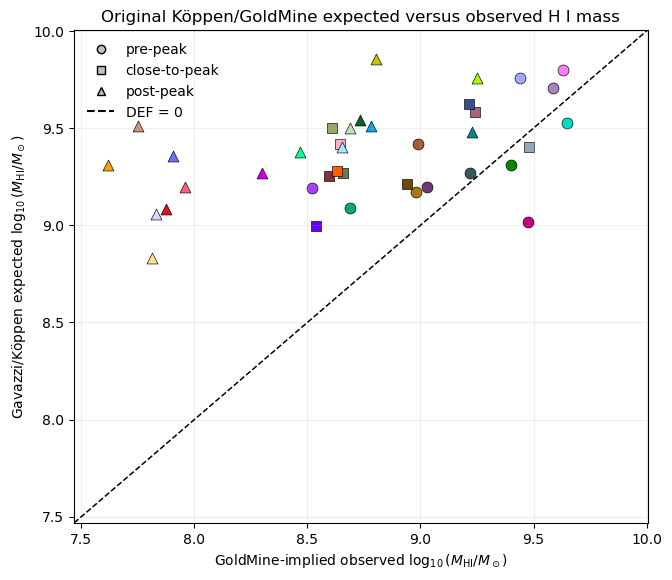

GoldMine Model-A negative-DEF galaxies (4): NGC4383, NGC4254, NGC4189, NGC4654


,Galaxy,stage_label,logMHIobs_ModelA_reconstructed,logMHI0_ModelA_reconstructed,DEF_ModelA
7,NGC4383,pre-peak,9.476,9.016,-0.46
3,NGC4254,pre-peak,9.647,9.527,-0.12
0,NGC4189,pre-peak,9.401,9.309,-0.09174
20,NGC4654,close-to-peak,9.482,9.402,-0.08


In [5]:
stage_markers = {1: "o", 2: "s", 3: "^"}
stage_labels = {1: "pre-peak", 2: "close-to-peak", 3: "post-peak"}

fig, ax = plt.subplots(figsize=(7.4, 6.4))
for _, row in sample.loc[available].iterrows():
    ax.scatter(
        row["logMHIobs_ModelA_reconstructed"], row["logMHI0_ModelA_reconstructed"],
        marker=stage_markers[row["stage"]], s=62, color=row["galaxy_color"],
        edgecolor="black", linewidth=0.45,
    )

limits = [
    min(sample.loc[available, "logMHIobs_ModelA_reconstructed"].min(),
        sample.loc[available, "logMHI0_ModelA_reconstructed"].min()) - 0.15,
    max(sample.loc[available, "logMHIobs_ModelA_reconstructed"].max(),
        sample.loc[available, "logMHI0_ModelA_reconstructed"].max()) + 0.15,
]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=1.1, label="DEF = 0")
ax.set(xlim=limits, ylim=limits,
       xlabel=r"GoldMine-implied observed $\log_{10}(M_{\rm HI}/M_\odot)$",
       ylabel=r"Gavazzi/Köppen expected $\log_{10}(M_{\rm HI}/M_\odot)$")
ax.grid(alpha=0.2)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles.append(Line2D([], [], color="black", linestyle="--", label="DEF = 0"))
ax.legend(handles=handles, frameon=False)
ax.set_title("Original Köppen/GoldMine expected versus observed H I mass")
plt.show()

negative_deficiency = sample.loc[
    available & (sample["DEF_ModelA"] < 0),
    ["Galaxy", "stage_label", "logMHIobs_ModelA_reconstructed", "logMHI0_ModelA_reconstructed", "DEF_ModelA"],
].sort_values("DEF_ModelA")
print(f"GoldMine Model-A negative-DEF galaxies ({len(negative_deficiency)}): " + ", ".join(negative_deficiency["Galaxy"]))
display(negative_deficiency)

## 6. Original Köppen profile and deficiency inversion

Köppen adopts

$$
\Sigma_{\rm HI}(r)=\frac{\Sigma_0}{[1+(r/R)^2]^{3/2}},
\quad R=R_{\rm opt},\quad r_{\max}=1.5R.
$$

With $C=1-[1+(r_{\max}/R)^2]^{-1/2}$ and $\Sigma_0=M_0/(2\pi R^2C)$, the analytic inversion is

$$
A=1-C10^{-\mathrm{DEF}},\qquad r_{\rm strip}=R\sqrt{A^{-2}-1}.
$$

The required pressure follows Köppen equation 27. The public companion calculator uses the numerical conversion constant `0.0675`; adopting it is necessary to reproduce Appendix E. Non-positive deficiencies have no physical truncation inversion and remain `NaN`.

In [6]:
def profile_integral_factor(ropt_kpc, rmax_kpc):
    ropt_kpc, rmax_kpc = np.broadcast_arrays(np.asarray(ropt_kpc, float), np.asarray(rmax_kpc, float))
    return 1.0 - 1.0 / np.sqrt(1.0 + (rmax_kpc / ropt_kpc) ** 2)


def stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc):
    deficiency, ropt_kpc, rmax_kpc = np.broadcast_arrays(
        np.asarray(deficiency, float), np.asarray(ropt_kpc, float), np.asarray(rmax_kpc, float)
    )
    result = np.full(deficiency.shape, np.nan)
    valid = (deficiency > 0) & (ropt_kpc > 0) & (rmax_kpc > 0)
    c_profile = profile_integral_factor(ropt_kpc[valid], rmax_kpc[valid])
    a_term = 1.0 - c_profile * np.power(10.0, -deficiency[valid])
    result[valid] = ropt_kpc[valid] * np.sqrt(np.power(a_term, -2.0) - 1.0)
    return result


def sigma_hi_msun_pc2(r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc):
    r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc = np.broadcast_arrays(
        np.asarray(r_kpc, float), np.asarray(ropt_kpc, float),
        np.asarray(log_mhi_initial, float), np.asarray(rmax_kpc, float)
    )
    c_profile = profile_integral_factor(ropt_kpc, rmax_kpc)
    sigma0 = np.power(10.0, log_mhi_initial) / (2.0 * np.pi * (ropt_kpc * 1_000.0) ** 2 * c_profile)
    return sigma0 / np.power(1.0 + (r_kpc / ropt_kpc) ** 2, 1.5)


def pressure_at_radius(r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms):
    sigma_at_r = sigma_hi_msun_pc2(r_kpc, ropt_kpc, log_mhi_initial, rmax_kpc)
    r0_kpc = R0_AT_ROPT_15_KPC * np.asarray(ropt_kpc) / 15.0
    stellar_boost = 1.0 + STELLAR_BOOST_A * np.exp(-np.asarray(r_kpc) / r0_kpc)
    return (sigma_at_r * np.asarray(vrot_kms) ** 2 / (RESTORING_G * np.asarray(r_kpc))
            * stellar_boost * KOPPEN_C1_PRESSURE / 1_000.0)


def required_pressure(deficiency, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms):
    r_strip = stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc)
    return pressure_at_radius(r_strip, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms)


test_def = np.array([1e-8, 0.1, 0.5, 1.0, 2.0])
test_r = stripping_radius_kpc(test_def, np.ones_like(test_def), 1.5)
assert np.isclose(test_r[0], 1.5, rtol=1e-6) and np.all(np.diff(test_r) < 0)
assert np.isnan(stripping_radius_kpc(np.array([-0.1, 0.0]), 1.0, 1.5)).all()
r_grid = np.linspace(0.0, 7.5, 200_001)
sigma_grid = sigma_hi_msun_pc2(r_grid, 5.0, 9.5, 7.5)
integrated_mass = np.trapezoid(2.0 * np.pi * (1_000.0 * r_grid) * sigma_grid * 1_000.0, r_grid)
assert np.isclose(integrated_mass, 10.0 ** 9.5, rtol=2e-5)
print("Original Model-A inversion and normalization checks passed.")

Original Model-A inversion and normalization checks passed.


## 7. Original Köppen local pressure and a non-adopted LOS comparison

Köppen's original local-pressure upper limit is

$$
p_{\rm loc}=n_{\rm ICM}(R_{\rm M87})v_{\rm esc}^2(R_{\rm M87}),
$$

using their spherical Virgo ICM and dark-matter beta models. `R_M87_ModelA_mpc` is the published Appendix-E distance for 35 rows and the same 3D GoldMine/M87 geometry for the three added rows.

For continuity with Model C, the table also lists $v_{\rm relative,LOS}=|v_{\rm LOS}-1256|$ and the larger comparison speed. However, **Model A adopts escape speed**. The LOS-based pressure is comparison-only and never enters the ratio or classification.

In [7]:
def escape_speed_squared_kms2(radius_kpc):
    radius_kpc = np.asarray(radius_kpc, dtype=float)
    x = radius_kpc / DM_RC_KPC
    shape = np.ones_like(x)
    nonzero = x != 0
    shape[nonzero] = np.arcsinh(x[nonzero]) / x[nonzero]
    rho0_msun_kpc3 = DM_RHO0_MSUN_PC3 * 1.0e9
    return 8.0 * np.pi * G_KPC_KMS2_MSUN * rho0_msun_kpc3 * DM_RC_KPC**2 * shape


def icm_number_density_cm3(radius_mpc):
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    return ICM_N0_CM3 * np.power(1.0 + (radius_kpc / ICM_RC_KPC) ** 2, -1.5 * ICM_BETA)


def local_pressure(radius_mpc, velocity_kms=None):
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    if velocity_kms is None:
        velocity_kms = np.sqrt(escape_speed_squared_kms2(radius_kpc))
    return icm_number_density_cm3(radius_mpc) * np.asarray(velocity_kms) ** 2 / 1_000.0


sample["Rproj_mpc"] = sample["R_M87_ModelA_mpc"]
sample["v_esc_kms"] = np.sqrt(escape_speed_squared_kms2(sample["Rproj_mpc"] * 1_000.0))
sample["n_icm_cm3"] = icm_number_density_cm3(sample["Rproj_mpc"])
sample["p_loc"] = local_pressure(sample["Rproj_mpc"])
sample["v_los_kms"] = sample["vel"].astype(float)
sample["v_relative_los_kms"] = np.abs(sample["v_los_kms"] - M87_VLOS_KMS)
sample["v_comparison_kms"] = np.maximum(sample["v_esc_kms"], sample["v_relative_los_kms"])
sample["v_comparison_source"] = np.where(sample["v_relative_los_kms"] > sample["v_esc_kms"],
                                                "LOS relative velocity", "Köppen escape speed")
sample["p_loc_LOS_comparison"] = local_pressure(sample["Rproj_mpc"], sample["v_comparison_kms"])

ploc_check = sample.loc[sample["in_K18_catalogue"] & (sample["p_loc_K18"] > 0), ["Galaxy", "Rproj_mpc", "p_loc_K18", "p_loc"]].copy()
ploc_check["fractional_residual"] = (ploc_check["p_loc"] - ploc_check["p_loc_K18"]) / ploc_check["p_loc_K18"]
assert ploc_check["fractional_residual"].abs().median() < 0.10
display(sample[["Galaxy", "in_K18_catalogue", "Rproj_mpc", "v_los_kms", "v_relative_los_kms",
                "v_esc_kms", "v_comparison_kms", "v_comparison_source",
                "p_loc_K18", "p_loc", "p_loc_LOS_comparison"]])
print("Original escape-only p_loc is adopted; LOS pressure is comparison-only.")

,Galaxy,in_K18_catalogue,Rproj_mpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_comparison_kms,v_comparison_source,p_loc_K18,p_loc,p_loc_LOS_comparison
0,NGC4189,False,15.1,1995,739,636.7,739,LOS relative velocity,NaN,0.0008067,0.001087
1,NGC4192,True,1.43,-118,1374,1440,1440,Köppen escape speed,0.1,0.1145,0.1145
2,NGC4222,True,1.08,225,1031,1551,1551,Köppen escape speed,0.18,0.1974,0.1974
3,NGC4254,True,1.05,2453,1197,1562,1562,Köppen escape speed,0.19,0.2084,0.2084
4,NGC4294,True,0.74,421,835,1693,1693,Köppen escape speed,0.38,0.4006,0.4006
5,NGC4321,True,1.17,1579,323,1520,1520,Köppen escape speed,0.16,0.1693,0.1693
6,NGC4351,True,3.35,2388,1132,1106,1132,LOS relative velocity,0.02,0.02034,0.02131
7,NGC4383,True,1.27,1663,407,1487,1487,Köppen escape speed,0.13,0.1444,0.1444
8,NGC4396,True,1.03,-115,1371,1570,1570,Köppen escape speed,0.2,0.2161,0.2161
9,NGC4535,True,1.27,1973,717,1487,1487,Köppen escape speed,0.13,0.1444,0.1444


Original escape-only p_loc is adopted; LOS pressure is comparison-only.


## 8. Deterministic reproduction of $p_{\rm def}$ and use of published $p_{\rm cfg}$

The central calculation uses Appendix-E values for 35 rows and directly audited GoldMine values for three added rows and the original equations. Recomputed $p_{\rm def}$ is compared with the rounded published value. Published $p_{\rm cfg}$ is retained directly because the paper sometimes substitutes morphology-specific bound-gas radii that cannot be reconstructed from the isophotal-radius column alone.

In [8]:
sample["r_strip_kpc"] = stripping_radius_kpc(sample["DEF_ModelA"], sample["Ropt_ModelA_kpc"], sample["rmax_kpc"])
sample["p_def"] = required_pressure(sample["DEF_ModelA"], sample["Ropt_ModelA_kpc"],
                                     sample["logMHI0_ModelA_reconstructed"], sample["rmax_kpc"],
                                     sample["vrot_ModelA_kms"])
sample["p_cfg"] = sample["p_cfg_K18"]
sample["pressure_ratio"] = sample["p_def"] / sample["p_loc"]
sample["Delta_RP"] = np.log10(sample["pressure_ratio"])
sample["p_cfg_over_p_loc"] = sample["p_cfg"] / sample["p_loc"]
sample["p_cfg_over_p_def"] = sample["p_cfg"] / sample["p_def"]
sample["deterministic_status"] = np.select(
    [~sample["modelA_computable"], sample["DEF_ModelA"] <= 0, sample["pressure_ratio"] > 2.0],
    ["GoldMine inclination=0: no vrot", "non-positive DEF: no inversion", "past-stripping favoured"],
    default="locally attainable / ongoing-compatible",
)

deterministic_columns = [
    "Galaxy", "stage_label", "in_K18_catalogue", "DEF_ModelA", "Ropt_ModelA_kpc",
    "logMHIobs_ModelA_reconstructed", "logMHI0_ModelA_reconstructed", "rmax_kpc", "r_strip_kpc",
    "vrot_ModelA_kms", "Rproj_mpc", "v_esc_kms", "v_relative_los_kms",
    "p_def_K18", "p_def", "p_cfg", "p_loc_K18", "p_loc", "p_loc_LOS_comparison",
    "pressure_ratio", "Delta_RP", "p_cfg_over_p_loc", "p_cfg_over_p_def", "deterministic_status",
]
display(sample[deterministic_columns])

,Galaxy,stage_label,in_K18_catalogue,DEF_ModelA,Ropt_ModelA_kpc,logMHIobs_ModelA_reconstructed,logMHI0_ModelA_reconstructed,rmax_kpc,r_strip_kpc,vrot_ModelA_kms,Rproj_mpc,v_esc_kms,v_relative_los_kms,p_def_K18,p_def,p_cfg,p_loc_K18,p_loc,p_loc_LOS_comparison,pressure_ratio,Delta_RP,p_cfg_over_p_loc,p_cfg_over_p_def,deterministic_status
0,NGC4189,pre-peak,False,-0.09174,10.52,9.401,9.309,15.78,NaN,179.6,15.1,636.7,739,NaN,NaN,NaN,NaN,0.0008067,0.001087,NaN,NaN,NaN,NaN,non-positive DEF: no inversion
1,NGC4192,pre-peak,True,0.17,24.2,9.631,9.801,36.3,24.76,234.7,1.43,1440,1374,0.1,0.09972,0.12,0.1,0.1145,0.1145,0.8708,-0.06008,1.048,1.203,locally attainable / ongoing-compatible
2,NGC4222,pre-peak,True,0.17,8.7,9.027,9.197,13.05,8.902,113,1.08,1551,1031,0.12,0.1238,0.13,0.18,0.1974,0.1974,0.6268,-0.2029,0.6584,1.05,locally attainable / ongoing-compatible
3,NGC4254,pre-peak,True,-0.12,15.2,9.647,9.527,22.8,NaN,271.4,1.05,1562,1197,NaN,NaN,0.92,0.19,0.2084,0.2084,NaN,NaN,4.415,NaN,non-positive DEF: no inversion
4,NGC4294,pre-peak,True,0.05,9.8,9.217,9.267,14.7,12.96,101.1,0.74,1693,835,0.04,0.04026,0.08,0.38,0.4006,0.4006,0.1005,-0.9978,0.1997,1.987,locally attainable / ongoing-compatible
5,NGC4321,pre-peak,True,0.32,22.5,9.438,9.758,33.75,17.65,268.8,1.17,1520,323,0.27,0.2839,0.27,0.16,0.1693,0.1693,1.677,0.2245,1.595,0.9511,locally attainable / ongoing-compatible
6,NGC4351,pre-peak,True,0.67,8.6,8.52,9.19,12.9,4.048,60.6,3.35,1106,1132,0.23,0.2446,0.09,0.02,0.02034,0.02131,12.02,1.08,4.425,0.368,past-stripping favoured
7,NGC4383,pre-peak,True,-0.46,6.4,9.476,9.016,9.6,NaN,123.6,1.27,1487,407,NaN,NaN,0.02,0.13,0.1444,0.1444,NaN,NaN,0.1385,NaN,non-positive DEF: no inversion
8,NGC4396,pre-peak,True,0.19,8.3,8.979,9.169,12.45,8.174,99,1.03,1570,1371,0.11,0.1132,0.08,0.2,0.2161,0.2161,0.5237,-0.2809,0.3701,0.7068,locally attainable / ongoing-compatible
9,NGC4535,pre-peak,True,0.12,20.6,9.586,9.706,30.9,23.31,297.9,1.27,1487,717,0.15,0.1603,0.22,0.13,0.1444,0.1444,1.11,0.04523,1.523,1.373,locally attainable / ongoing-compatible


## 9. Monte Carlo uncertainty model

Section 7.2 of Köppen reports empirical cross-catalogue differences that are propagated transparently:

| Quantity | Draw used here |
|---|---|
| deficiency | Gaussian $\sigma=0.22$ dex |
| optical radius | log-normal $\sigma=0.08$ dex |
| rotation speed | Gaussian $\sigma=15$ km s$^{-1}$ |
| $p_{\rm loc}$ model | factor-of-two log-normal uncertainty |

Each draw recomputes $D_{\rm opt}=2R_{\rm opt}$, the Gavazzi initial mass, and $r_{\max}=1.5R_{\rm opt}$. The LOS comparison is not sampled because it is not part of Model A. The three fully specified live-GoldMine rows receive the same draws. Only NGC4394 and NGC4457 receive no pressure draws because their inclination-corrected rotation speed is undefined.

In [9]:
ratio_draws = {}


def q16_50_84(values):
    finite = np.asarray(values)[np.isfinite(values)]
    if finite.size == 0:
        return np.nan, np.nan, np.nan
    return tuple(np.percentile(finite, [16, 50, 84]))


def monte_carlo_row(row, rng, n_draws=N_MC):
    keys = ["DEF_p16", "DEF_p50", "DEF_p84", "rmax_p16", "rmax_p50", "rmax_p84",
            "ratio_p16", "ratio_p50", "ratio_p84", "Delta_RP_p16", "Delta_RP_p50",
            "Delta_RP_p84", "p_def_p16", "p_def_p50", "p_def_p84",
            "P_DEF_positive", "P_past_joint", "P_past_given_DEF_positive"]
    if not row.modelA_computable:
        ratio_draws[row.Galaxy] = np.array([], dtype=float)
        return {key: np.nan for key in keys}

    deficiency = rng.normal(row.DEF_ModelA, SIGMA_DEF_DEX, n_draws)
    ropt_kpc = row.Ropt_ModelA_kpc * np.power(10.0, rng.normal(0.0, SIGMA_LOG_ROPT_DEX, n_draws))
    rmax_kpc = 1.5 * ropt_kpc
    log_mhi_initial = gavazzi_log_mhi_initial(2.0 * ropt_kpc)
    vrot = np.clip(rng.normal(row.vrot_ModelA_kms, row.e_vrot_used, n_draws), 1.0, None)
    p_def = required_pressure(deficiency, ropt_kpc, log_mhi_initial, rmax_kpc, vrot)
    p_loc = row.p_loc * np.power(10.0, rng.normal(0.0, SIGMA_LOG_PLOC_DEX, n_draws))
    valid = np.isfinite(p_def) & (deficiency > 0.0)
    ratio = np.where(valid, p_def / p_loc, np.nan)
    ratio_draws[row.Galaxy] = ratio[np.isfinite(ratio)]
    past = valid & (ratio > 2.0)
    d_q, r_q, delta_q = q16_50_84(deficiency), q16_50_84(ratio), q16_50_84(np.log10(ratio))
    pdef_q, rmax_q = q16_50_84(np.where(valid, p_def, np.nan)), q16_50_84(rmax_kpc)
    return {
        "DEF_p16": d_q[0], "DEF_p50": d_q[1], "DEF_p84": d_q[2],
        "rmax_p16": rmax_q[0], "rmax_p50": rmax_q[1], "rmax_p84": rmax_q[2],
        "ratio_p16": r_q[0], "ratio_p50": r_q[1], "ratio_p84": r_q[2],
        "Delta_RP_p16": delta_q[0], "Delta_RP_p50": delta_q[1], "Delta_RP_p84": delta_q[2],
        "p_def_p16": pdef_q[0], "p_def_p50": pdef_q[1], "p_def_p84": pdef_q[2],
        "P_DEF_positive": valid.mean(), "P_past_joint": past.mean(),
        "P_past_given_DEF_positive": past.sum() / valid.sum() if valid.any() else np.nan,
    }


rng = np.random.default_rng(RNG_SEED)
mc = pd.DataFrame([monte_carlo_row(row, rng) for row in sample.itertuples(index=False)])
results = pd.concat([sample.reset_index(drop=True), mc], axis=1)


def mc_interpretation(row):
    if not row.modelA_computable:
        return "GoldMine inclination=0: no vrot"
    if row.P_DEF_positive < 0.5:
        return "mostly non-deficient / inversion unstable"
    if row.P_past_given_DEF_positive >= 0.84:
        return "past-stripping favoured"
    if row.P_past_given_DEF_positive <= 0.16:
        return "ongoing-compatible"
    return "ambiguous"


results["MC_interpretation"] = results.apply(mc_interpretation, axis=1)
mc_columns = ["Galaxy", "stage_label", "in_K18_catalogue", "DEF_p16", "DEF_p50", "DEF_p84",
              "rmax_p16", "rmax_p50", "rmax_p84", "P_DEF_positive",
              "ratio_p16", "ratio_p50", "ratio_p84", "Delta_RP_p50",
              "P_past_joint", "P_past_given_DEF_positive", "MC_interpretation"]
display(results[mc_columns])

,Galaxy,stage_label,in_K18_catalogue,DEF_p16,DEF_p50,DEF_p84,rmax_p16,rmax_p50,rmax_p84,P_DEF_positive,ratio_p16,ratio_p50,ratio_p84,Delta_RP_p50,P_past_joint,P_past_given_DEF_positive,MC_interpretation
0,NGC4189,pre-peak,False,-0.3057,-0.09224,0.1265,13.13,15.77,18.92,0.3347,88.38,231.6,611,2.365,0.3347,1,mostly non-deficient / inversion unstable
1,NGC4192,pre-peak,True,-0.04409,0.1706,0.3843,30.26,36.37,43.66,0.7812,0.4094,1.153,3.316,0.06186,0.2384,0.3051,ambiguous
2,NGC4222,pre-peak,True,-0.0516,0.1686,0.3878,10.88,13.02,15.69,0.78,0.2885,0.8239,2.399,-0.08411,0.1598,0.2049,ambiguous
3,NGC4254,pre-peak,True,-0.3393,-0.1236,0.09456,18.95,22.69,27.32,0.2893,0.4218,1.059,2.802,0.02471,0.0744,0.2572,mostly non-deficient / inversion unstable
4,NGC4294,pre-peak,True,-0.1669,0.05177,0.2703,12.22,14.67,17.64,0.5935,0.07635,0.21,0.5722,-0.6777,0.0081,0.01365,ongoing-compatible
5,NGC4321,pre-peak,True,0.1029,0.3224,0.5403,28.14,33.87,40.66,0.926,0.6039,1.795,5.22,0.254,0.4281,0.4623,ambiguous
6,NGC4351,pre-peak,True,0.4506,0.6705,0.8895,10.77,12.86,15.46,0.9989,4.124,12.08,35.19,1.082,0.9488,0.9499,past-stripping favoured
7,NGC4383,pre-peak,True,-0.6738,-0.459,-0.2405,7.988,9.602,11.54,0.01665,0.4125,0.9582,2.364,-0.01855,0.0034,0.2042,mostly non-deficient / inversion unstable
8,NGC4396,pre-peak,True,-0.02551,0.1901,0.4114,10.35,12.44,14.98,0.8088,0.2343,0.6698,1.941,-0.174,0.1239,0.1531,ongoing-compatible
9,NGC4535,pre-peak,True,-0.101,0.1203,0.3405,25.69,30.95,37.15,0.708,0.6185,1.713,4.975,0.2337,0.3145,0.4441,ambiguous


### 9.1 Per-galaxy probability-density views of $p_{\rm def}/p_{\rm loc}$

The 40 panels below expose the full strict Model-A Monte Carlo shape instead of reducing each galaxy to one probability.

- Each histogram is normalized as a probability density and uses only draws with a physical positive-deficiency inversion.
- The solid line marks $p_{\rm def}/p_{\rm loc}=1$; the dotted line marks the Köppen factor-of-two boundary.
- The horizontal axis is logarithmic because the pressure ratio spans several orders of magnitude.
- `P(DEF>0)` states how often an inversion exists at all. `P(>2 | DEF>0)` measures the past-stripping probability conditional on those physical draws.

The conditional histogram must therefore be read together with `P(DEF>0)`. For example, a distribution based on only a tiny fraction of positive-DEF draws is not strong evidence even if those few draws lie beyond a reference line.

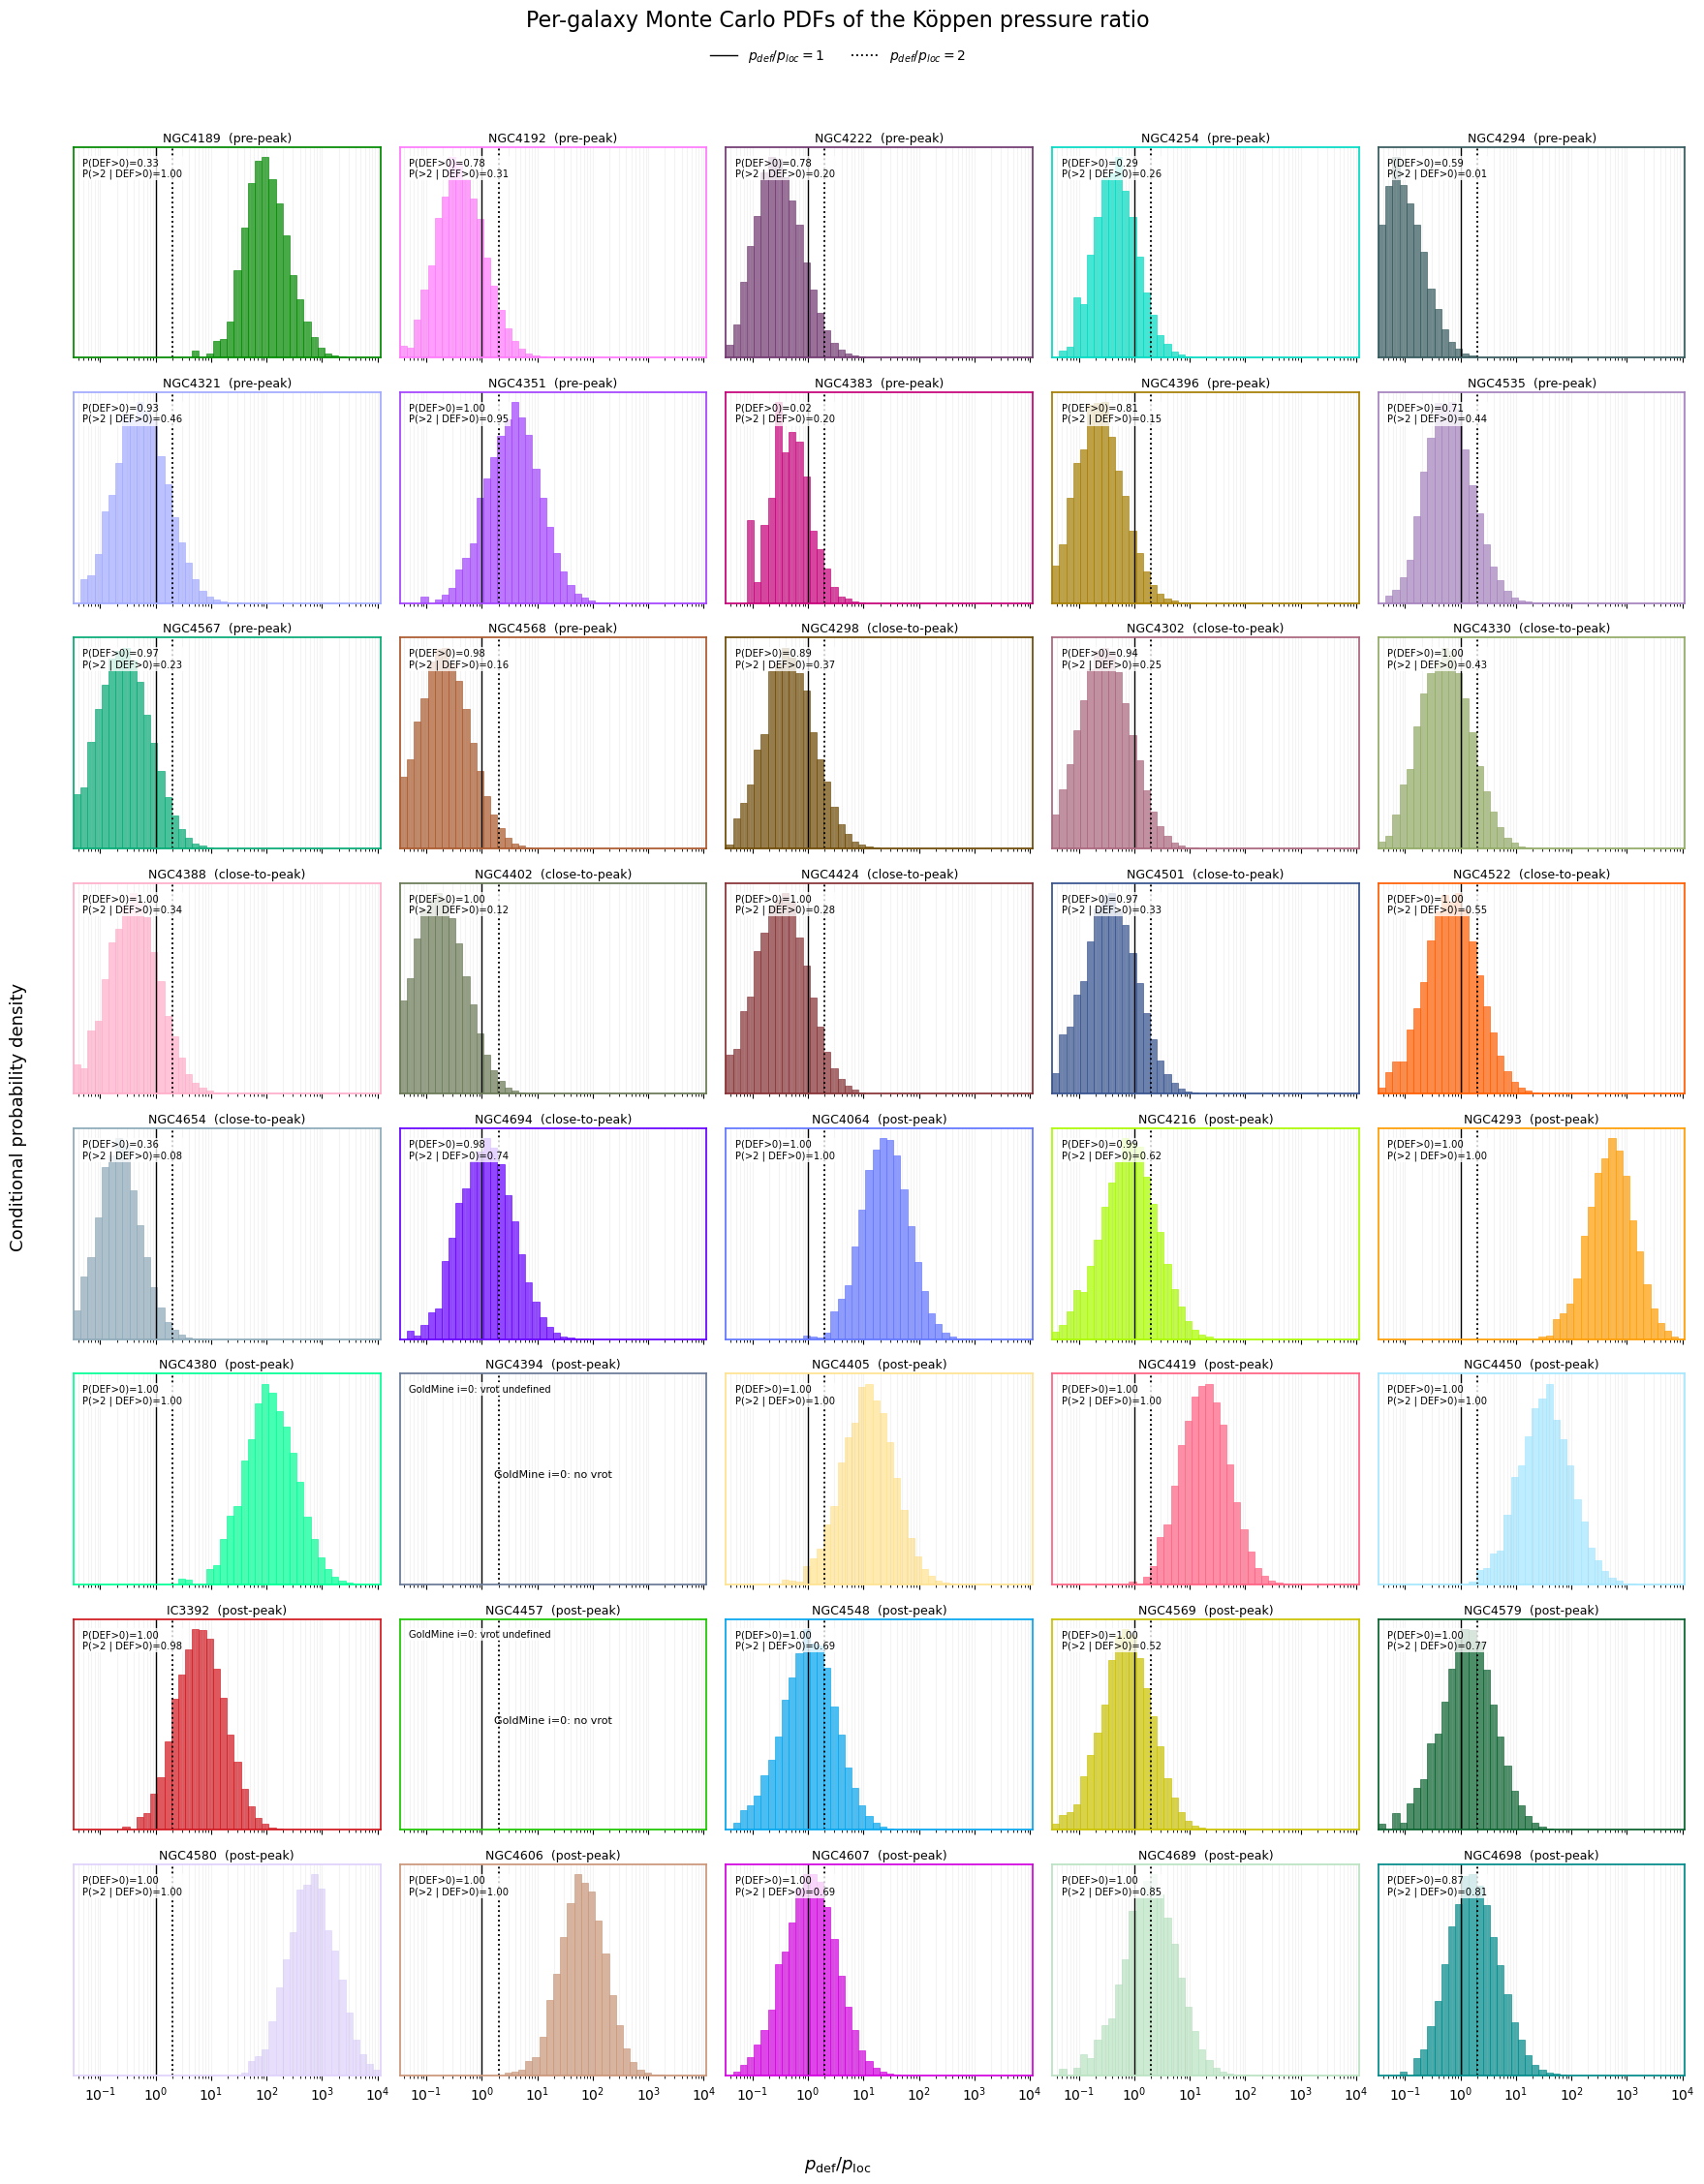

In [10]:
# Use common logarithmic bins so all 40 panels are directly comparable.
all_ratio_values = np.concatenate([values for values in ratio_draws.values() if len(values) > 0])
x_min = min(0.25, np.percentile(all_ratio_values, 0.1))
x_max = max(4.0, np.percentile(all_ratio_values, 99.9))
ratio_bins = np.geomspace(x_min, x_max, 45)

fig, axes = plt.subplots(8, 5, figsize=(18, 23), sharex=True)
axes = axes.ravel()

for ax, row in zip(axes, results.itertuples(index=False)):
    values = ratio_draws[row.Galaxy]
    if len(values) > 0:
        ax.hist(
            values,
            bins=ratio_bins,
            density=True,
            color=row.galaxy_color,
            alpha=0.72,
            edgecolor=row.galaxy_color,
            linewidth=0.6,
        )
    else:
        message = "GoldMine i=0: no vrot" if not row.modelA_computable else "No positive-DEF draws"
        ax.text(0.5, 0.52, message, transform=ax.transAxes,
                ha="center", va="center", fontsize=8)

    ax.axvline(1.0, color="black", linewidth=1.0)
    ax.axvline(2.0, color="black", linestyle=":", linewidth=1.35)
    ax.set_xscale("log")
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.grid(axis="x", which="both", alpha=0.15)
    ax.set_title(f"{row.Galaxy}  ({row.stage_label})", fontsize=9, pad=4)
    stats_text = (
        f"P(DEF>0)={row.P_DEF_positive:.2f}\n"
        f"P(>2 | DEF>0)={row.P_past_given_DEF_positive:.2f}"
        if row.modelA_computable else "GoldMine i=0: vrot undefined"
    )
    ax.text(
        0.03, 0.95, stats_text,
        transform=ax.transAxes, ha="left", va="top", fontsize=7.2,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 1.2},
    )
    for spine in ax.spines.values():
        spine.set_edgecolor(row.galaxy_color)
        spine.set_linewidth(1.25)

fig.supxlabel(r"$p_{\rm def}/p_{\rm loc}$", fontsize=13, y=0.025)
fig.supylabel("Conditional probability density", fontsize=13, x=0.025)
fig.suptitle(
    "Per-galaxy Monte Carlo PDFs of the Köppen pressure ratio",
    fontsize=16, y=0.997,
)
fig.legend(
    handles=[
        Line2D([], [], color="black", linewidth=1.0, label=r"$p_{def}/p_{loc}=1$"),
        Line2D([], [], color="black", linestyle=":", linewidth=1.35,
               label=r"$p_{def}/p_{loc}=2$"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 0.985), ncol=2, frameon=False,
)
fig.tight_layout(rect=(0.035, 0.035, 1.0, 0.965), h_pad=1.1, w_pad=0.7)
plt.show()

## 10. Main pressure-plane result

The left panel shows deterministic central $p_{\rm def}$ against central $p_{\rm loc}$. The added right panel shows the corresponding **central** ratio $p_{\rm def}/p_{\rm loc}$ galaxy by galaxy; it contains no Monte Carlo summaries. The solid and dotted reference lines mark ratios 1 and 2.

Galaxies with non-positive central deficiency have no physical deficiency-inverted stripping radius. They are not plotted in either central-value panel and are named explicitly in the right-panel title and printed text.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


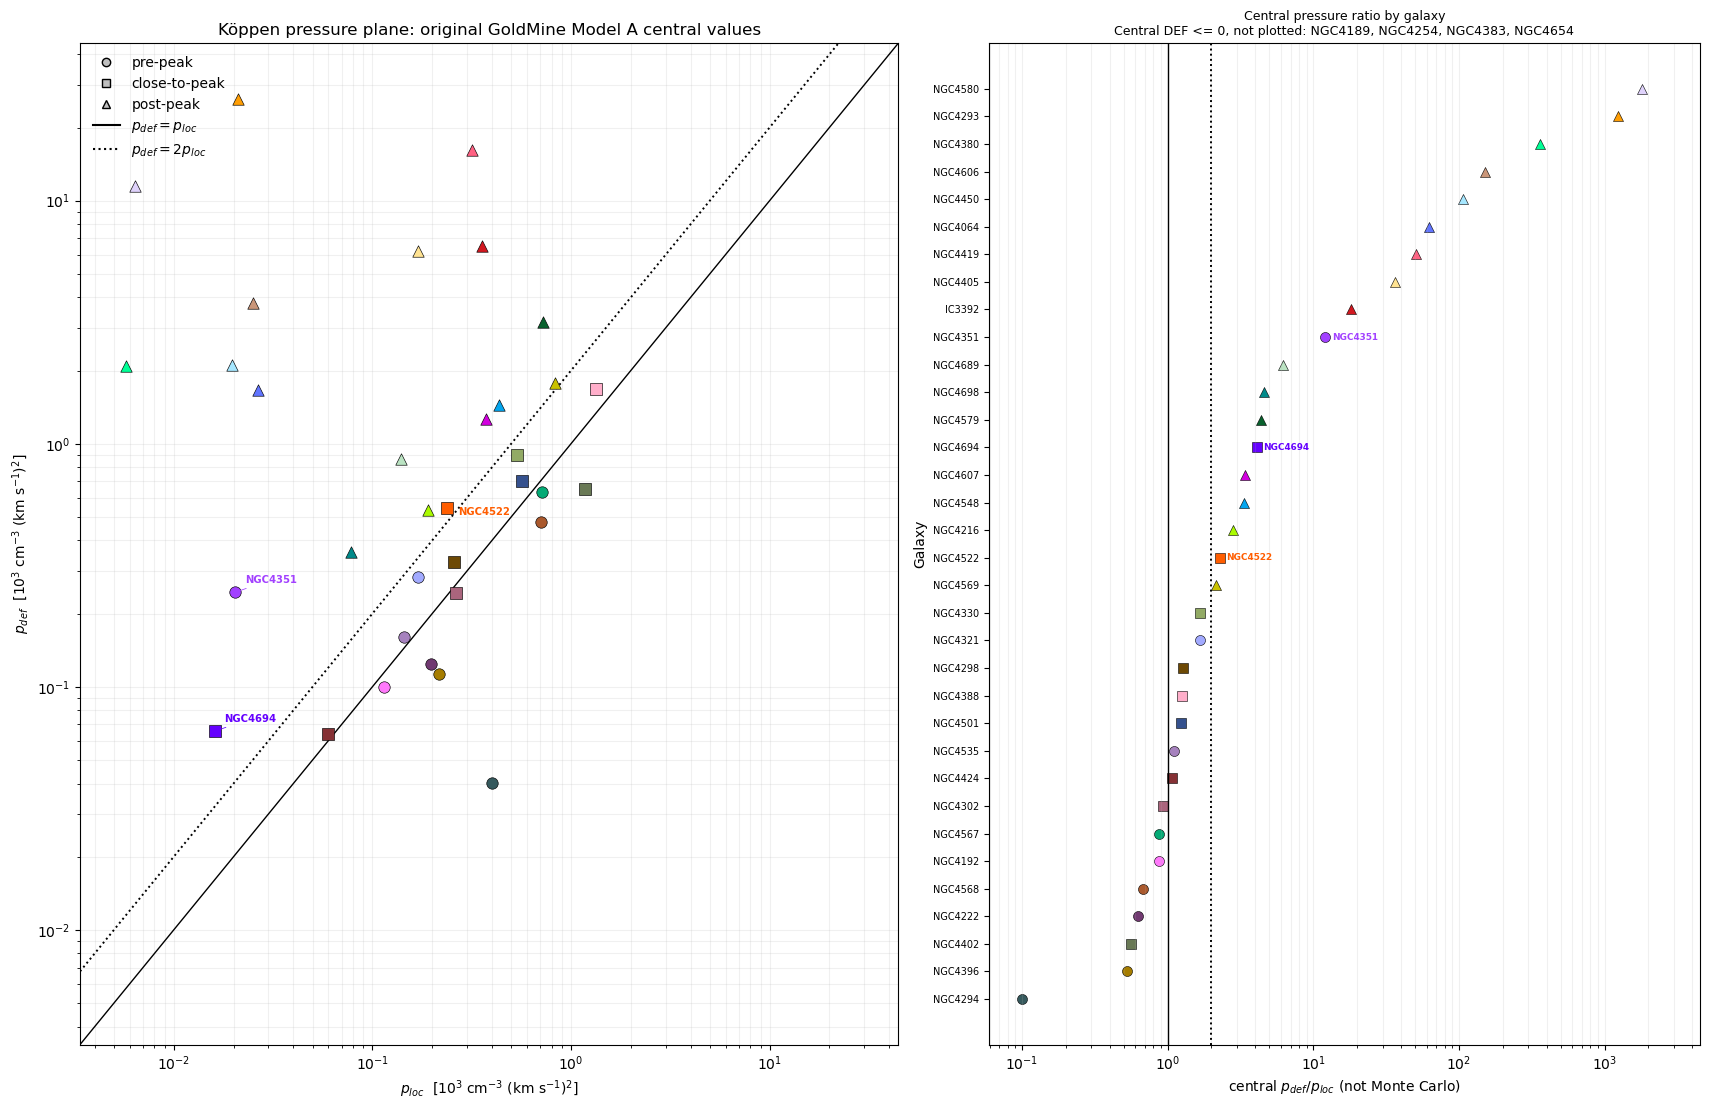

Central DEF <= 0 (not plotted in central-ratio panel): NGC4189, NGC4254, NGC4383, NGC4654
Pre-/close-to-peak galaxies with deterministic p_def/p_loc > 2: NGC4351, NGC4694, NGC4522


,Galaxy,stage_label,p_def,p_loc,pressure_ratio,Delta_RP
6,NGC4351,pre-peak,0.2446,0.02034,12.02,1.08
21,NGC4694,close-to-peak,0.06561,0.01607,4.083,0.611
19,NGC4522,close-to-peak,0.5417,0.2375,2.28,0.358


Central-ratio pre-/close-to-peak galaxies above 2: NGC4351, NGC4522, NGC4694


In [11]:
# Cross-diagnostic tension: MAUVE pre-/close-to-peak but central ratio > 2.
results["deterministic_nonpost_ratio_gt2"] = (
    results["stage"].isin([1, 2])
    & np.isfinite(results["pressure_ratio"])
    & (results["pressure_ratio"] > 2.0)
)

pressure_label_offsets = {
    "NGC4535": (-34, 15),
    "NGC4321": (8, -13), "NGC4192": (8, -3),
    "NGC4298": (-28, 11), "NGC4501": (7, 7),
    "NGC4522": (8, -5), "NGC4302": (9, -14),
}
fig, (ax_plane, ax_ratio) = plt.subplots(
    1, 2, figsize=(17.2, 11.2), gridspec_kw={"width_ratios": [1.15, 1.0]}
)
finite = np.isfinite(results["p_def"]) & np.isfinite(results["p_loc"])

for _, row in results.loc[finite].iterrows():
    ax_plane.scatter(
        row["p_loc"], row["p_def"], s=68,
        marker=stage_markers[row["stage"]], color=row["galaxy_color"],
        edgecolor="black", linewidth=0.45, zorder=3,
    )
    if row["deterministic_nonpost_ratio_gt2"]:
        ax_plane.annotate(
            row["Galaxy"], (row["p_loc"], row["p_def"]),
            xytext=pressure_label_offsets.get(row["Galaxy"], (7, 7)),
            textcoords="offset points", fontsize=7.2, fontweight="bold",
            color=row["galaxy_color"],
            arrowprops={"arrowstyle": "-", "color": row["galaxy_color"], "lw": 0.55},
            zorder=4,
        )

lo = min(results.loc[finite, ["p_loc", "p_def"]].min()) / 1.7
hi = max(results.loc[finite, ["p_loc", "p_def"]].max()) * 1.7
grid = np.geomspace(lo, hi, 300)
ax_plane.plot(grid, grid, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_plane.plot(grid, 2.0 * grid, color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_plane.set_xscale("log")
ax_plane.set_yscale("log")
ax_plane.set(xlim=(lo, hi), ylim=(lo, hi),
             xlabel=r"$p_{loc}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]",
             ylabel=r"$p_{def}$  [$10^3$ cm$^{-3}$ (km s$^{-1}$)$^2$]")
ax_plane.grid(which="both", alpha=0.18)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles += [Line2D([], [], color="black", label=r"$p_{def}=p_{loc}$"),
            Line2D([], [], color="black", linestyle=":", label=r"$p_{def}=2p_{loc}$")]
ax_plane.legend(handles=handles, frameon=False, loc="upper left")
ax_plane.set_title("Köppen pressure plane: original GoldMine Model A central values")

# Added central-value ratio panel. It contains no Monte Carlo summaries.
central_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_ranked = results.loc[central_valid].sort_values("pressure_ratio").reset_index(drop=True)
ypos = np.arange(len(central_ranked))
for y, (_, row) in zip(ypos, central_ranked.iterrows()):
    ax_ratio.scatter(
        row["pressure_ratio"], y, s=52, color=row["galaxy_color"],
        marker=stage_markers[row["stage"]], edgecolor="black", linewidth=0.4,
    )
    if row["stage"] in (1, 2) and row["pressure_ratio"] > 2.0:
        ax_ratio.annotate(
            row["Galaxy"], (row["pressure_ratio"], y),
            xytext=(5, 0), textcoords="offset points", ha="left", va="center",
            fontsize=6.4, fontweight="bold", color=row["galaxy_color"],
        )
ax_ratio.set_xlim(
    central_ranked["pressure_ratio"].min() / 1.7,
    central_ranked["pressure_ratio"].max() * 2.5,
)
ax_ratio.axvline(1.0, color="black", linewidth=1.0)
ax_ratio.axvline(2.0, color="black", linestyle=":", linewidth=1.4)
ax_ratio.set_xscale("log")
ax_ratio.set_yticks(ypos, central_ranked["Galaxy"], fontsize=7)
ax_ratio.set_xlabel(r"central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_ratio.set_ylabel("Galaxy")
ax_ratio.grid(axis="x", which="both", alpha=0.18)
negative_central_names = results.loc[results["DEF_ModelA"] <= 0, "Galaxy"].tolist()
ax_ratio.set_title(
    "Central pressure ratio by galaxy\n"
    + "Central DEF <= 0, not plotted: " + ", ".join(negative_central_names),
    fontsize=9,
)
fig.tight_layout()
plt.show()
print("Central DEF <= 0 (not plotted in central-ratio panel): " + ", ".join(negative_central_names))

deterministic_stage_tension = (
    results.loc[results["deterministic_nonpost_ratio_gt2"]]
    .sort_values(["stage", "pressure_ratio"], ascending=[True, False])
    [["Galaxy", "stage_label", "p_def", "p_loc", "pressure_ratio", "Delta_RP"]]
)
print(
    "Pre-/close-to-peak galaxies with deterministic p_def/p_loc > 2: "
    + ", ".join(deterministic_stage_tension["Galaxy"])
)
display(deterministic_stage_tension)
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 11. Stage comparison: Monte Carlo and central values

The left panel shows the Monte Carlo median $\Delta_{\rm RP}$ with its 16th–84th percentile interval. The added right panel recomputes the stage comparison from the deterministic central $p_{\rm def}/p_{\rm loc}$ values only.

Central non-positive-deficiency galaxies are excluded from the right-panel points and named in its text box. For Model A only, the earlier NGC4189-specific edit is revoked: the MC label selection again requires $P({\rm DEF}>0)\geq0.5$, so NGC4189 is not labelled as a robust MC tension. It remains named in the central-panel negative-DEF text.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def}/p_{\rm loc}>2$ is annotated by name in the new central panel.


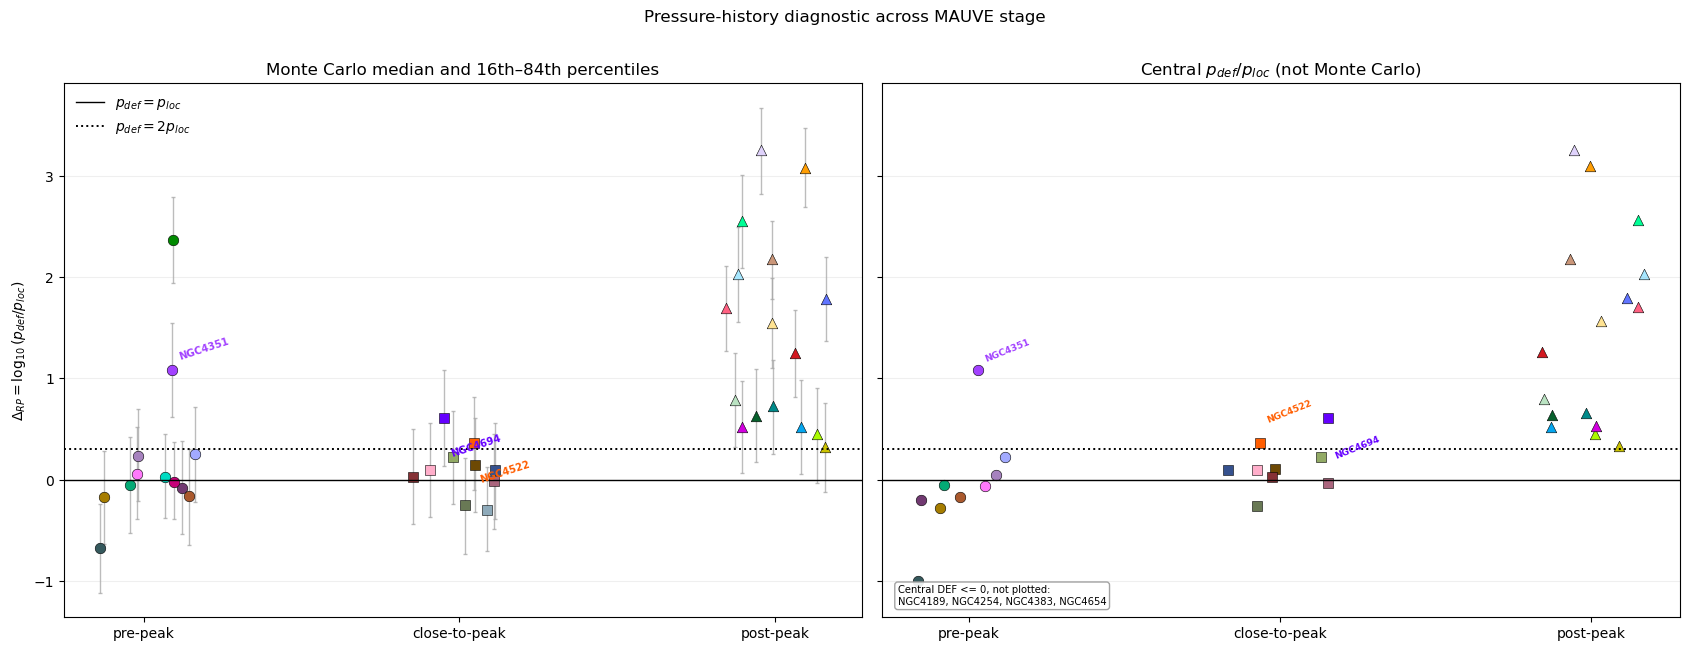

Pre-/close-to-peak galaxies satisfying the displayed MC selection: NGC4351, NGC4694, NGC4522


,Galaxy,stage_label,ratio_p16,ratio_p50,ratio_p84,P_DEF_positive,P_past_given_DEF_positive
6,NGC4351,pre-peak,4.124,12.08,35.19,0.9989,0.9499
21,NGC4694,close-to-peak,1.368,4.11,12.11,0.9809,0.7437
19,NGC4522,close-to-peak,0.7891,2.295,6.598,0.9983,0.5518


Central-ratio pre-/close-to-peak galaxies above 2: NGC4351, NGC4522, NGC4694


In [12]:
# Label pre-/close-to-peak Monte Carlo medians above the factor-of-two line.
results["mc_median_nonpost_ratio_gt2"] = (
    results["stage"].isin([1, 2])
    & np.isfinite(results["ratio_p50"])
    & (results["P_DEF_positive"] >= 0.5)
    & (results["ratio_p50"] > 2.0)
)

fig, (ax_mc, ax_central) = plt.subplots(1, 2, figsize=(17.0, 6.4), sharey=True)
jitter_rng = np.random.default_rng(42)

for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & np.isfinite(results["Delta_RP_p50"])]
    x = stage + jitter_rng.uniform(-0.17, 0.17, len(group))
    y = group["Delta_RP_p50"].to_numpy()
    yerr = np.vstack([
        y - group["Delta_RP_p16"].to_numpy(),
        group["Delta_RP_p84"].to_numpy() - y,
    ])
    ax_mc.errorbar(x, y, yerr=yerr, fmt="none", ecolor="0.65", alpha=0.75,
                   elinewidth=1.0, capsize=1.5, zorder=1)
    for label_number, (xpos, (_, row)) in enumerate(zip(x, group.iterrows())):
        ax_mc.scatter(xpos, row["Delta_RP_p50"], s=58, color=row["galaxy_color"],
                      marker=stage_markers[stage], edgecolor="black", linewidth=0.4, zorder=2)
        if row["mc_median_nonpost_ratio_gt2"]:
            y_offset = 6 if label_number % 2 == 0 else -11
            ax_mc.annotate(
                row["Galaxy"], (xpos, row["Delta_RP_p50"]),
                xytext=(4, y_offset), textcoords="offset points",
                fontsize=7.2, fontweight="bold", color=row["galaxy_color"],
                rotation=18, ha="left", va="bottom" if y_offset > 0 else "top",
                zorder=3,
            )

ax_mc.axhline(0.0, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_mc.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_mc.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_mc.set_ylabel(r"$\Delta_{RP}=\log_{10}(p_{def}/p_{loc})$")
ax_mc.set_title("Monte Carlo median and 16th–84th percentiles")
ax_mc.grid(axis="y", alpha=0.2)
ax_mc.legend(frameon=False)

# Added central-value stage panel. Negative/non-positive central deficiencies
# are deliberately absent because their stripping-radius inversion is undefined.
central_stage_valid = np.isfinite(results["pressure_ratio"]) & (results["pressure_ratio"] > 0)
central_jitter_rng = np.random.default_rng(43)
central_label_number = 0
for stage in (1, 2, 3):
    group = results[(results["stage"] == stage) & central_stage_valid]
    x = stage + central_jitter_rng.uniform(-0.17, 0.17, len(group))
    for xpos, (_, row) in zip(x, group.iterrows()):
        central_y = np.log10(row["pressure_ratio"])
        ax_central.scatter(
            xpos, central_y, s=58,
            color=row["galaxy_color"], marker=stage_markers[stage],
            edgecolor="black", linewidth=0.4,
        )
        if stage in (1, 2) and row["pressure_ratio"] > 2.0:
            label_offsets = [(4, 5), (4, 14), (4, -12)]
            offset = label_offsets[central_label_number % len(label_offsets)]
            ax_central.annotate(
                row["Galaxy"], (xpos, central_y), xytext=offset,
                textcoords="offset points", fontsize=6.6, fontweight="bold",
                color=row["galaxy_color"], rotation=22, ha="left",
                va="bottom" if offset[1] >= 0 else "top", zorder=3,
            )
            central_label_number += 1
ax_central.axhline(0.0, color="black", linewidth=1.0)
ax_central.axhline(np.log10(2.0), color="black", linestyle=":", linewidth=1.4)
ax_central.set_xticks([1, 2, 3], [stage_labels[s] for s in (1, 2, 3)])
ax_central.set_title("Central $p_{def}/p_{loc}$ (not Monte Carlo)")
ax_central.grid(axis="y", alpha=0.2)
negative_central_names = results.loc[results["DEF_ModelA"] <= 0, "Galaxy"].tolist()
ax_central.text(
    0.02, 0.02, "Central DEF <= 0, not plotted:\n" + ", ".join(negative_central_names),
    transform=ax_central.transAxes, ha="left", va="bottom", fontsize=7.2,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.6", "alpha": 0.9},
)
fig.suptitle("Pressure-history diagnostic across MAUVE stage", y=1.01)
fig.tight_layout()
plt.show()

mc_stage_tension = (
    results.loc[results["mc_median_nonpost_ratio_gt2"]]
    .sort_values(["stage", "ratio_p50"], ascending=[True, False])
    [["Galaxy", "stage_label", "ratio_p16", "ratio_p50", "ratio_p84",
      "P_DEF_positive", "P_past_given_DEF_positive"]]
)
print(
    "Pre-/close-to-peak galaxies satisfying the displayed MC selection: "
    + ", ".join(mc_stage_tension["Galaxy"])
)
display(mc_stage_tension)
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["pressure_ratio"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 12. Stage summaries and direct reproduction checks

The stage table counts both the 35 directly published rows and all 38 computable GoldMine Model-A rows. The reproduction table remains restricted to Appendix E, so its $p_{\rm def}$ and $p_{\rm loc}$ regression is not circularly extended to the three newly computed galaxies.

In [13]:
stage_summary = (
    results.groupby(["stage", "stage_label"], observed=True)
    .agg(N_MAUVE=("Galaxy", "size"), N_K18=("in_K18_catalogue", "sum"),
         N_ModelA=("modelA_computable", "sum"),
         median_DEF=("DEF_p50", "median"), median_Delta_RP=("Delta_RP_p50", "median"),
         median_P_DEF_positive=("P_DEF_positive", "median"),
         median_P_past_given_positive=("P_past_given_DEF_positive", "median"),
         N_past_favoured=("MC_interpretation", lambda x: (x == "past-stripping favoured").sum()),
         N_ambiguous=("MC_interpretation", lambda x: (x == "ambiguous").sum()),
         N_ongoing_compatible=("MC_interpretation", lambda x: (x == "ongoing-compatible").sum()),
         N_no_vrot=("MC_interpretation", lambda x: (x == "GoldMine inclination=0: no vrot").sum()))
    .reset_index()
)
display(stage_summary)

reproduction = results.loc[results["in_K18_catalogue"], [
    "Galaxy", "DEF_ModelA", "Ropt_ModelA_kpc", "vrot_ModelA_kms",
    "p_def_K18", "p_def", "p_loc_K18", "p_loc", "p_cfg_K18"]].copy()
reproduction["pdef_recomputed_over_published"] = reproduction["p_def"] / reproduction["p_def_K18"]
reproduction["ploc_recomputed_over_published"] = reproduction["p_loc"] / reproduction["p_loc_K18"]
display(reproduction)
finite_pdef_check = reproduction["pdef_recomputed_over_published"].replace([np.inf, -np.inf], np.nan).dropna()
finite_ploc_check = reproduction["ploc_recomputed_over_published"].replace([np.inf, -np.inf], np.nan).dropna()
print(f"Median p_def recomputed/published: {finite_pdef_check.median():.3f}")
print(f"Median p_loc recomputed/published: {finite_ploc_check.median():.3f}")

,stage,stage_label,N_MAUVE,N_K18,N_ModelA,median_DEF,median_Delta_RP,median_P_DEF_positive,median_P_past_given_positive,N_past_favoured,N_ambiguous,N_ongoing_compatible,N_no_vrot
0,1,pre-peak,12,9,12,0.1696,0.003078,0.7806,0.244,1,6,2,0
1,2,close-to-peak,10,10,10,0.5373,0.09754,0.9894,0.3348,0,8,1,0
2,3,post-peak,18,16,16,0.9954,1.402,1,0.9907,10,6,0,2


,Galaxy,DEF_ModelA,Ropt_ModelA_kpc,vrot_ModelA_kms,p_def_K18,p_def,p_loc_K18,p_loc,p_cfg_K18,pdef_recomputed_over_published,ploc_recomputed_over_published
1,NGC4192,0.17,24.2,234.7,0.1,0.09972,0.1,0.1145,0.12,0.9972,1.145
2,NGC4222,0.17,8.7,113,0.12,0.1238,0.18,0.1974,0.13,1.031,1.097
3,NGC4254,-0.12,15.2,271.4,NaN,NaN,0.19,0.2084,0.92,NaN,1.097
4,NGC4294,0.05,9.8,101.1,0.04,0.04026,0.38,0.4006,0.08,1.007,1.054
5,NGC4321,0.32,22.5,268.8,0.27,0.2839,0.16,0.1693,0.27,1.051,1.058
6,NGC4351,0.67,8.6,60.6,0.23,0.2446,0.02,0.02034,0.09,1.063,1.017
7,NGC4383,-0.46,6.4,123.6,NaN,NaN,0.13,0.1444,0.02,NaN,1.111
8,NGC4396,0.19,8.3,99,0.11,0.1132,0.2,0.2161,0.08,1.029,1.081
9,NGC4535,0.12,20.6,297.9,0.15,0.1603,0.13,0.1444,0.22,1.069,1.111
12,NGC4298,0.27,8.9,148.8,0.31,0.3257,0.24,0.257,0.37,1.051,1.071


Median p_def recomputed/published: 1.051
Median p_loc recomputed/published: 1.058


## 13. Automated QC and interpretation guardrails

- Retain all 40 identities, 35 directly published Appendix-E rows, and 38 computable Model-A rows.
- Require the two non-computable names to be exactly NGC4394 and NGC4457 and document their $i=0^\circ$ singularity.
- Require $r_{\max}=1.5R_{\rm opt}$ and escape-only $p_{\rm loc}$ for all 38 computable rows.
- Require physical inversion only for positive deficiency.
- Regression-test recomputed pressures against the 35 rounded Appendix-E rows.
- Keep all probabilities in $[0,1]$.

The added-row velocity conversion is an explicitly documented inference from the published/live GoldMine overlap, not an equation printed in Köppen's text.

In [14]:
expected_e_vrot_used = np.where(
    np.isfinite(results["e_vrot_literature"]) & (results["e_vrot_literature"] > 0),
    results["e_vrot_literature"],
    VROT_FRACTIONAL_FALLBACK * results["vrot_ModelA_kms"],
)
assert np.allclose(results["e_vrot_used"], expected_e_vrot_used, equal_nan=True)

assert len(results) == 40 and results["Galaxy"].nunique() == 40
assert results["in_K18_catalogue"].sum() == 35
assert results["modelA_computable"].sum() == 38
assert results.loc[results["modelA_computable"], "e_vrot_used"].gt(0).all()
assert set(results.loc[~results["modelA_computable"], "Galaxy"]) == {"NGC4394", "NGC4457"}
assert set(results["stage"]) == {1, 2, 3}
usable = results["modelA_computable"]
assert results.loc[usable, ["DEF_ModelA", "Ropt_ModelA_kpc", "rmax_kpc", "vrot_ModelA_kms", "Rproj_mpc", "p_loc"]].notna().all().all()
assert np.allclose(results.loc[usable, "rmax_kpc"], 1.5 * results.loc[usable, "Ropt_ModelA_kpc"])
assert np.allclose(results.loc[usable, "pressure_ratio"], results.loc[usable, "p_def"] / results.loc[usable, "p_loc"], equal_nan=True)

positive_def = usable & (results["DEF_ModelA"] > 0)
assert results.loc[positive_def, ["r_strip_kpc", "p_def", "pressure_ratio"]].notna().all().all()
assert results.loc[usable & ~positive_def, ["r_strip_kpc", "p_def", "pressure_ratio"]].isna().all().all()
assert results.loc[~usable, "r_strip_kpc"].notna().all()
assert results.loc[~usable, ["p_def", "pressure_ratio"]].isna().all().all()
assert results.loc[~usable, "p_loc"].notna().all()
assert results.loc[~usable, "vrot_ModelA_kms"].isna().all()
for column in ["P_DEF_positive", "P_past_joint", "P_past_given_DEF_positive"]:
    assert results[column].dropna().between(0.0, 1.0).all()
assert (results.loc[usable, "P_past_joint"] <= results.loc[usable, "P_DEF_positive"] + 1e-12).all()
assert np.median(np.abs(finite_pdef_check - 1.0)) < 0.08
assert np.max(np.abs(finite_pdef_check - 1.0)) < 0.12
assert np.median(np.abs(finite_ploc_check - 1.0)) < 0.10
print("All strict Model-A QC checks passed.")
print(f"Computable positive central DEF: {positive_def.sum()}/38")
display(results["MC_interpretation"].value_counts().rename_axis("interpretation").to_frame("N"))

All strict Model-A QC checks passed.
Computable positive central DEF: 34/38


,N
interpretation,
ambiguous,20
past-stripping favoured,11
mostly non-deficient / inversion unstable,4
ongoing-compatible,3
GoldMine inclination=0: no vrot,2


## 14. How to read and extend this notebook

### Ready to use

- 35 original Appendix-E rows plus three additional rows reconstructed entirely from audited GoldMine fields with the Köppen/Gavazzi equations.
- Recomputed $r_{\rm strip}$, $p_{\rm def}$, escape-only $p_{\rm loc}$, published $p_{\rm cfg}$ where available, uncertainty intervals, and 40 explicit PDF panels.
- Separate provenance flags for “published in Köppen” and “computable with Model A.”

### Limitations

1. **NGC4394 and NGC4457:** GoldMine records their `MHI_GM` and `WIDTHA`, but $i=0^\circ$ makes $v_{\rm rot}\propto1/\sin i$ undefined. Computing their pressure requires an external inclination or rotation velocity and would be a hybrid extension.
2. **Added-row velocity inference:** the factor 0.98 is validated empirically against Appendix E but is not explicitly printed as an equation in the paper.
3. **NGC4189 location:** its GoldMine distance of 32 Mpc places it about 15.1 Mpc from M87; it is non-deficient in the reconstructed Model A and therefore has no $p_{\rm def}$ inversion.
4. **Rounded source table and uncertainty model:** regression is tolerance based and paper-level scatters are not row-level likelihoods.
5. **Published $p_{\rm cfg}$:** retained directly because every morphology-specific bound-gas radius is not encoded in Appendix E.
6. **Original geometry:** LOS pressure is diagnostic only; Model A adopts escape-only $p_{\rm loc}$.

An optional hybrid sensitivity run could add literature inclinations or resolved $v_{\rm rot}$ for NGC4394 and NGC4457, but it should not be labelled exact GoldMine Model A.

In [15]:
ranked = results[[
    "Galaxy", "stage_label", "in_K18_catalogue", "modelA_computable", "DEF_p50", "rmax_p50",
    "P_DEF_positive", "ratio_p50", "P_past_given_DEF_positive", "P_past_joint",
    "p_cfg_over_p_loc", "p_cfg_over_p_def", "MC_interpretation", "K18_input_source",
]].sort_values(["modelA_computable", "in_K18_catalogue", "P_past_given_DEF_positive", "P_DEF_positive"],
               ascending=[False, False, False, False], na_position="last")
display(ranked)

nonpost_ratio_gt2 = results.loc[
    results["deterministic_nonpost_ratio_gt2"] | results["mc_median_nonpost_ratio_gt2"]
].sort_values(["stage", "ratio_p50"], ascending=[True, False])[[
    "Galaxy", "stage_label", "pressure_ratio", "ratio_p16", "ratio_p50", "ratio_p84",
    "P_DEF_positive", "P_past_given_DEF_positive",
    "deterministic_nonpost_ratio_gt2", "mc_median_nonpost_ratio_gt2"]]
display(Markdown("### Pre-/close-to-peak galaxies above the factor-of-two boundary"))
display(nonpost_ratio_gt2)

display(Markdown("### GoldMine records that still lack a computable Köppen rotation speed"))
display(results.loc[~results["modelA_computable"], [
    "Galaxy", "stage_label", "GoldMine_live_audit_note",
    "logMHI_GoldMine_live", "W50_GoldMine_live_kms", "WIDTHA_GoldMine_live_kms"]])
display(Markdown(
    "**Take-home rule:** use the continuous ratio and interval for the 38 computable objects; ""the direct Appendix-E reproduction check remains restricted to 35; "
    "use published $p_{cfg}$ only where finite; and treat the two inclination-zero panels as missing pressure constraints."
))

,Galaxy,stage_label,in_K18_catalogue,modelA_computable,DEF_p50,rmax_p50,P_DEF_positive,ratio_p50,P_past_given_DEF_positive,P_past_joint,p_cfg_over_p_loc,p_cfg_over_p_def,MC_interpretation,K18_input_source
24,NGC4293,post-peak,True,True,1.69,15.79,1,1201,1,1,NaN,NaN,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
25,NGC4380,post-peak,True,True,0.9094,17.68,1,359.8,1,1,121.9,0.3363,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
35,NGC4580,post-peak,True,True,1.228,10.32,1,1791,1,1,375.2,0.2075,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
36,NGC4606,post-peak,True,True,1.758,22.17,1,149.8,1,1,26.74,0.176,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
29,NGC4450,post-peak,True,True,0.7493,18.44,0.9997,106.3,0.9999,0.9996,41.58,0.3899,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
22,NGC4064,post-peak,True,True,1.45,17.07,1,61.27,0.9999,0.9999,12.08,0.1929,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
28,NGC4419,post-peak,True,True,1.239,13.06,1,49.83,0.9996,0.9996,9.49,0.186,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
27,NGC4405,post-peak,True,True,1.018,7.045,1,35.52,0.9966,0.9966,7.974,0.218,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
30,IC3392,post-peak,True,True,1.212,10.78,1,17.92,0.9848,0.9848,NaN,NaN,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...
6,NGC4351,pre-peak,True,True,0.6705,12.86,0.9989,12.08,0.9499,0.9488,4.425,0.368,past-stripping favoured,Koppen2018 Appendix E; GoldMine-derived publis...


### Pre-/close-to-peak galaxies above the factor-of-two boundary

,Galaxy,stage_label,pressure_ratio,ratio_p16,ratio_p50,ratio_p84,P_DEF_positive,P_past_given_DEF_positive,deterministic_nonpost_ratio_gt2,mc_median_nonpost_ratio_gt2
6,NGC4351,pre-peak,12.02,4.124,12.08,35.19,0.9989,0.9499,True,True
21,NGC4694,close-to-peak,4.083,1.368,4.11,12.11,0.9809,0.7437,True,True
19,NGC4522,close-to-peak,2.28,0.7891,2.295,6.598,0.9983,0.5518,True,True


### GoldMine records that still lack a computable Köppen rotation speed

,Galaxy,stage_label,GoldMine_live_audit_note,logMHI_GoldMine_live,W50_GoldMine_live_kms,WIDTHA_GoldMine_live_kms
26,NGC4394,post-peak,"GoldMine MHI_GM and WIDTHA exist, but inclinat...",8.51,NaN,174
31,NGC4457,post-peak,"GoldMine MHI_GM and WIDTHA exist, but inclinat...",8.35,NaN,172


**Take-home rule:** use the continuous ratio and interval for the 38 computable objects; the direct Appendix-E reproduction check remains restricted to 35; use published $p_{cfg}$ only where finite; and treat the two inclination-zero panels as missing pressure constraints.